<a href="https://colab.research.google.com/github/NegasaReta/Elevvo-Internship-Machine-Learning-Track/blob/Task-2/Task2_Customer_Segmentation_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import the important Libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans  #first algorithm used
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering #2nd algorithm used
from sklearn.cluster import DBSCAN #third algorithm used

##Load the dataset

In [4]:
try:
    df = pd.read_csv('/content/Mall_Customers.csv')
    print("Dataset loaded successfully.")
    print("-" * 30)
    print(df.head())
except FileNotFoundError:
    print("Error: 'Mall_Customers.csv' not found. Please upload the file to the Colab files section.")

Dataset loaded successfully.
------------------------------
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

## Select features for clustering
##We typically use Annual Income and Spending Score for 2D visualization

In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

## 2. DATA PREPROCESSING (SCALING)

#Standardizing the data is important for K-Means to ensure features are on the same scale

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##3. ELBOW METHOD (FIND OPTIMAL K)

In [8]:
# We calculate the Within-Cluster Sum of Squares (WCSS) for different numbers of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


# Plot the Elbow Graph

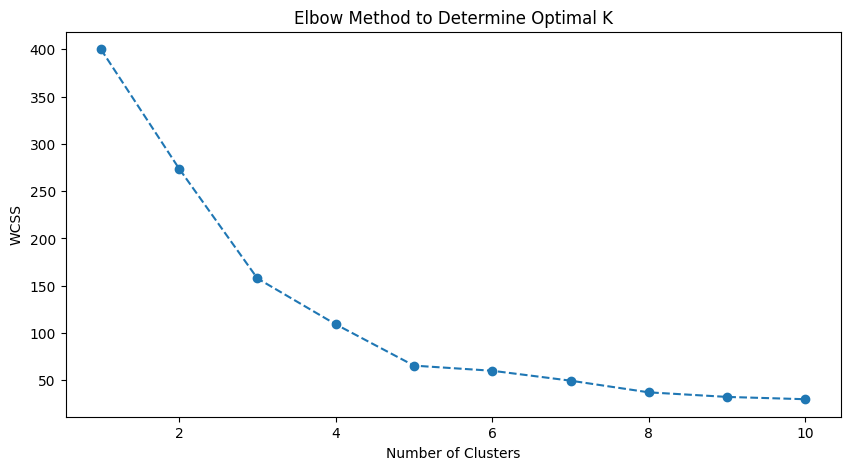

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

## 4. APPLY K-MEANS CLUSTERING

Based on the typical Mall Dataset, the elbow usually occurs at K=5

In [11]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

Add the cluster labels back to the original dataframe for interpretation

In [12]:
df['Cluster'] = y_kmeans

## 5. VISUALIZE CLUSTERS

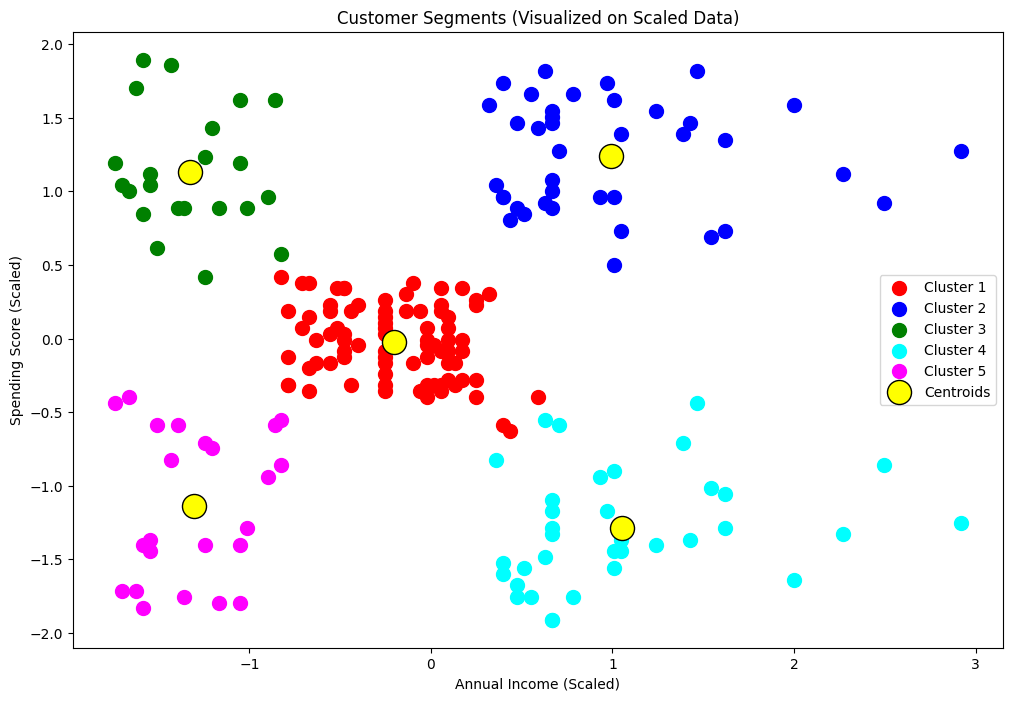

In [23]:
plt.figure(figsize=(12, 8))
# Define colors for the clusters
colors = ['red', 'blue', 'green', 'cyan', 'magenta']

# Plot each cluster
for i in range(optimal_k):
    # We plot the SCALED data points belonging to cluster 'i'
    plt.scatter(X_scaled[y_kmeans == i, 0], X_scaled[y_kmeans == i, 1],
                s=100, c=colors[i], label=f'Cluster {i+1}')
# Plot the Centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', label='Centroids', edgecolors='black')
plt.title('Customer Segments (Visualized on Scaled Data)')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()
plt.show()

##6. CLUSTER ANALYSIS

In [19]:
print("\nCluster Profiling (Mean Values of Original Data):")
# Group by cluster and calculate the mean of the original features
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(profile)


Cluster Profiling (Mean Values of Original Data):
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


# **BONUS IMPLIMENTATION**

#Algorithm Used: **AgglomerativeClustering**


## 1. DENDROGRAM (Visualizing the Hierarchy)

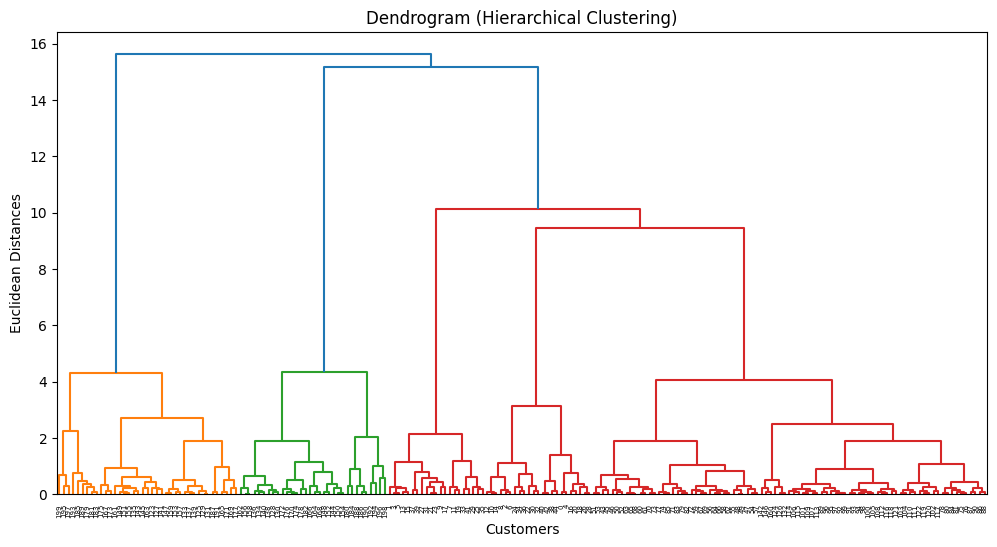

In [25]:
plt.figure(figsize=(12, 6))
plt.title('Dendrogram (Hierarchical Clustering)')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')

# 'ward' linkage minimizes the variance of clusters being merged
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.show()

# 2. APPLY HIERARCHICAL CLUSTERING

In [26]:
# Based on the Dendrogram (and our previous K-Means), 5 clusters is optimal
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X_scaled)

In [27]:
# Add the new labels to our DataFrame
df['HC_Cluster'] = y_hc


## 3. VISUALIZE HIERARCHICAL CLUSTERS

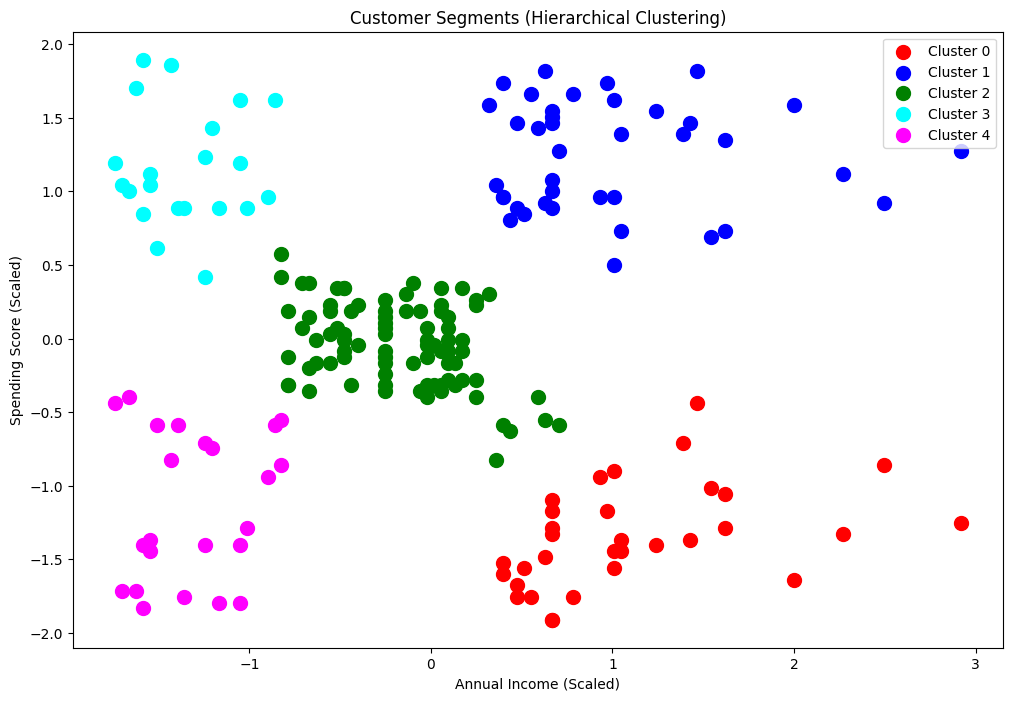

In [28]:
plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(5):
    plt.scatter(X_scaled[y_hc == i, 0], X_scaled[y_hc == i, 1],
                s=100, c=colors[i], label=f'Cluster {i}')

plt.title('Customer Segments (Hierarchical Clustering)')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()
plt.show()

## 4. DETAILED SPENDING ANALYSIS (Box Plots)

/tmp/ipython-input-300/22333768.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HC_Cluster', y='Spending Score (1-100)', data=df, palette='Set2')


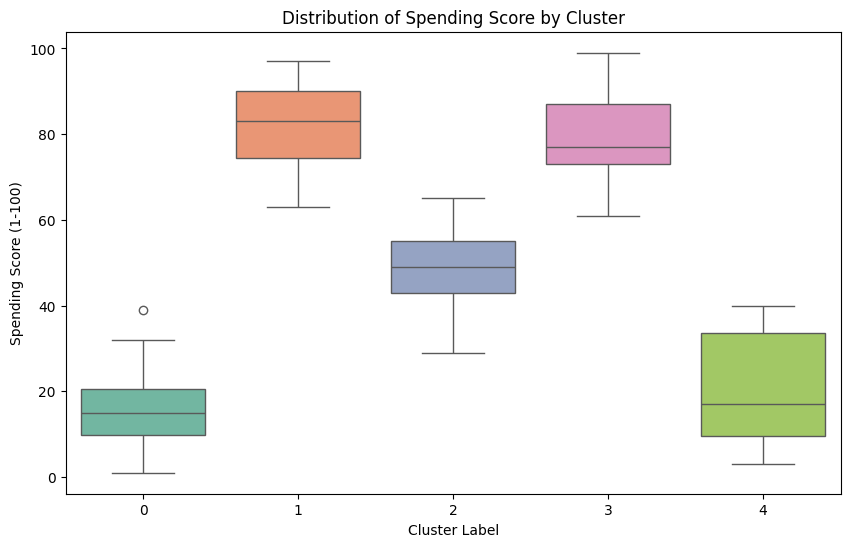

In [29]:

plt.figure(figsize=(10, 6))
# Create a boxplot to show distribution of Spending Score for each cluster
sns.boxplot(x='HC_Cluster', y='Spending Score (1-100)', data=df, palette='Set2')
plt.title('Distribution of Spending Score by Cluster')
plt.xlabel('Cluster Label')
plt.ylabel('Spending Score (1-100)')
plt.show()

## Display detailed stats (Mean, Median, Min, Max) for Spending Score

In [30]:
print("\nDetailed Spending Analysis per Cluster:")
stats = df.groupby('HC_Cluster')['Spending Score (1-100)'].agg(['mean', 'median', 'min', 'max', 'std'])
print(stats)


Detailed Spending Analysis per Cluster:
                 mean  median  min  max        std
HC_Cluster                                        
0           15.593750    15.0    1   39   8.936548
1           82.128205    83.0   63   97   9.364489
2           49.129412    49.0   29   65   7.281399
3           80.047619    77.0   61   99  10.249274
4           20.913043    17.0    3   40  13.017167


#Second Algorithm Used: **DBSCAN**

# 1. APPLY DBSCAN

# **eps**: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
# **min_samples**: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.
# These parameters often need tuning. For Mall Customers, 0.3 to 0.5 works well with scaled data.

In [33]:
dbscan = DBSCAN(eps=0.35, min_samples=4)
y_dbscan = dbscan.fit_predict(X_scaled)

In [34]:
# Add DBSCAN labels to DataFrame
df['DBSCAN_Cluster'] = y_dbscan


## 2. VISUALIZE DBSCAN CLUSTERS

In [35]:
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

## Get unique clusters (including -1 for noise)

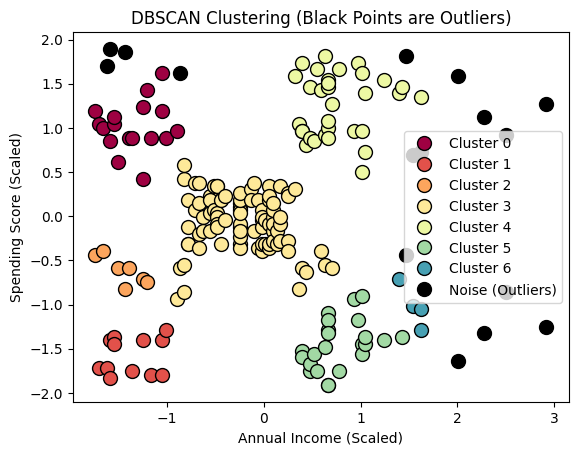

In [36]:
unique_labels = set(y_dbscan)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]
        label = "Noise (Outliers)"
    else:
        label = f"Cluster {k}"

    class_member_mask = (y_dbscan == k)

    xy = X_scaled[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=10, label=label)

plt.title('DBSCAN Clustering (Black Points are Outliers)')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()
plt.show()

## 3. ANALYZE OUTLIERS

In [38]:
n_clusters_ = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise_ = list(y_dbscan).count(-1)

print(f"\nEstimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points (outliers): {n_noise_}")


Estimated number of clusters: 7
Estimated number of noise points (outliers): 16


In [40]:
# Show the first few outliers found
print("\nSample Outliers (Customers who don't fit normal patterns):")
print(df[df['DBSCAN_Cluster'] == -1].head())


Sample Outliers (Customers who don't fit normal patterns):
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
7             8  Female   23                  18                      94   
11           12  Female   35                  19                      99   
19           20  Female   35                  23                      98   
41           42    Male   24                  38                      92   
184         185  Female   41                  99                      39   

     Cluster  HC_Cluster  DBSCAN_Cluster  
7          2           3              -1  
11         2           3              -1  
19         2           3              -1  
41         2           3              -1  
184        3           0              -1  


# 📊 **Customer Segmentation Analysis: Summary & Conclusion**

## **1. Project Overview**
The objective of this analysis was to segment the customers of a mall based on their **Annual Income** and **Spending Score**. We aimed to identify distinct groups of customers to enable targeted marketing strategies.

We implemented three different clustering algorithms to ensure robust and insightful results:
1.  **K-Means Clustering** (The Standard Approach)
2.  **Hierarchical Clustering** (The Structural Approach)
3.  **DBSCAN** (The Density/Anomaly Detection Approach)

---

## **2. Algorithm Performance & Findings**

### **A. K-Means Clustering (The Baseline)**
*   **Method:** Used the **Elbow Method** to determine the optimal number of clusters ($K=5$).
*   **Result:** Successfully identified **5 distinct customer segments**:
    1.  **Standard:** Average Income, Average Spending.
    2.  **Target (VIP):** High Income, High Spending.
    3.  **Careless:** Low Income, High Spending.
    4.  **Sensible:** Low Income, Low Spending.
    5.  **Savers:** High Income, Low Spending.
*   **Verdict:** Best for general marketing strategies. The clusters are well-balanced and easy to interpret.

### **B. Hierarchical Clustering (The Validator)**
*   **Method:** Used a **Dendrogram** to visualize the relationships between customers.
*   **Result:** Confirmed the optimal cluster count of **5**. The dendrogram structure closely mirrored the K-Means results.
*   **Spending Analysis:** Box plots revealed that the "VIP" cluster (High Income, High Spending) has a high median spending score (~83) with low variance, making them a very reliable target group.
*   **Verdict:** Validated the stability of the 5-cluster model.

### **C. DBSCAN (The Anomaly Detector)**
*   **Method:** Density-Based Spatial Clustering to find arbitrary shapes and outliers.
*   **Result:** Identified **7 Clusters** and **16 Outliers** (Noise points).
*   **Key Insight:**
    *   Found **"Super Extreme"** customers (e.g., Income 19k, Score 99) who were too unique to fit into the standard 5 clusters.
    *   Suggested that some of the 5 main groups might actually consist of smaller, denser subgroups.
*   **Verdict:** Best for identifying fraud, anomalies, or "Hyper-Specific" niche marketing (e.g., the top 1% of spenders).

---

## **3. Business Recommendations**

Based on the synthesis of all three models, we recommend a **Tiered Marketing Strategy**:

1.  **Primary Focus (The VIPs):**
    *   **Who:** High Income, High Spending (Cluster 1 from K-Means).
    *   **Action:** Loyalty programs, exclusive event invites, and premium product showcases. They are consistent and high-value.

2.  **Secondary Focus (The Potential):**
    *   **Who:** High Income, Low Spending (The "Savers").
    *   **Action:** Value-proposition marketing. Show them *why* spending is worth it. They have the budget but need a reason to buy.

3.  **Niche Focus (The Anomalies):**
    *   **Who:** The 16 Outliers identified by DBSCAN.
    *   **Action:** Investigate manually. If they are real high-value anomalies, offer personalized concierge services. If they are data errors, clean the database.

## **4. Conclusion**
The analysis confirms that a **5-Cluster Model** (derived from K-Means and validated by Hierarchical Clustering) is the most practical solution for broad customer segmentation. However, the **DBSCAN analysis** adds critical value by highlighting outliers that would otherwise be hidden in the averages.